In [48]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import config
import os, sys
config.update("jax_enable_x64", True)
import pickle
import time
from pathlib import Path
project_root = Path().resolve()              # e.g. /workspaces/TIME_DOMAIN_WORK
simphony_path = project_root / "simphony"    # relative clone folder
sys.path.insert(0, str(simphony_path))
import simphony
from scipy import signal
from simphony.utils import SPEED_OF_LIGHT
from simphony.libraries import siepic,ideal
from simphony.time_domain.ideal import Modulator
from simphony.time_domain.simulation import TimeResult, TimeSim
from simphony.time_domain.utils import gaussian_pulse, smooth_rectangular_pulse
from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline
from scipy.interpolate import interp1d
import contextlib

In [49]:
weights_pos =[(1.5090389251708984-0.39406076073646545j), (-0.02254176326096058+0.2515658736228943j), (-1.819382667541504-0.22460536658763885j), (-0.8253945112228394+0.9981537461280823j), (-0.5082707405090332+1.18967604637146j), (-0.0001774576521711424-0.6961514949798584j), (-0.03673146292567253+0.44644805788993835j), (-0.1459171175956726+0.06807226687669754j), (-0.5036165714263916-0.720775306224823j), (0.22833532094955444-0.6702100038528442j), (0.4913672208786011-0.5054720640182495j), (0.23964214324951172-0.17941826581954956j), (-0.8479951620101929+0.7080851793289185j), (-0.13165295124053955+1.22820246219635j), (-0.3264063894748688+0.9105650782585144j), (-0.5630364418029785+0.12412437796592712j), (0.6648470163345337-0.021696971729397774j), (0.768333911895752-0.26949793100357056j), (0.18256008625030518+1.3365470170974731j), (0.3749624788761139+0.6753222942352295j), (-0.007524069398641586+0.12470445781946182j), (0.24145781993865967-1.1117314100265503j), (-2.0713939666748047+0.13644053041934967j), (0.6786695718765259-0.9033428430557251j), (-0.7801675200462341+0.8043974041938782j)]
weights_neg =[(1.1716632843017578+0.8445451259613037j), (-0.7019909024238586-0.5123153328895569j), (1.5928280353546143-0.8183402419090271j), (-0.48552241921424866+1.1273351907730103j), (-0.4933079779148102-0.3121565878391266j), (0.5230439305305481+0.8503711819648743j), (1.3481826782226562-1.3615267276763916j), (-0.31822851300239563-0.6919068694114685j), (0.6234993934631348-0.5789737701416016j), (0.27767032384872437-0.08296317607164383j), (0.24960929155349731-0.014554109424352646j), (-0.5633884072303772+0.04182880371809006j), (-0.95609050989151-0.6565830707550049j), (0.7877309918403625+0.15527625381946564j), (0.29248183965682983+0.6491250991821289j), (0.03677031770348549+0.43369022011756897j), (0.6928834915161133-1.2170876264572144j), (-1.004181146621704-0.21675696969032288j), (-0.40289801359176636+1.09256911277771j), (-1.348107933998108-0.8007844686508179j), (-0.506431519985199+0.20231975615024567j), (-0.6783027648925781-0.6386787295341492j), (-0.9982107281684875+0.07071749120950699j), (0.5076889991760254-0.5713299512863159j), (0.4646381139755249+0.3727649748325348j)]

bias = -0.5240516066551208

In [50]:
data = np.load("X_mmi_binary_10.npz")
X_re    = data["X_re"]
X_im    = data["X_im"]
y = data["labels"]
y_data = np.asarray(y, dtype=float)
X_data    = X_re + 1j * X_im  


def split_pos_neg(X_raw):
    xpos_list = []
    xneg_list = []
    for i in range(0, 50, 10):
        xpos_list.append(X_raw[:, i:i+5])  # pos: first 5 ports
        xneg_list.append(X_raw[:, i+5:i+10])  # neg: next 5 ports
    xpos = np.concatenate(xpos_list, axis=1)  # shape: (N, 25)
    xneg = np.concatenate(xneg_list, axis=1)  # shape: (N, 25)
    return xpos, xneg

xpos_old, xneg_old = split_pos_neg(X_data)



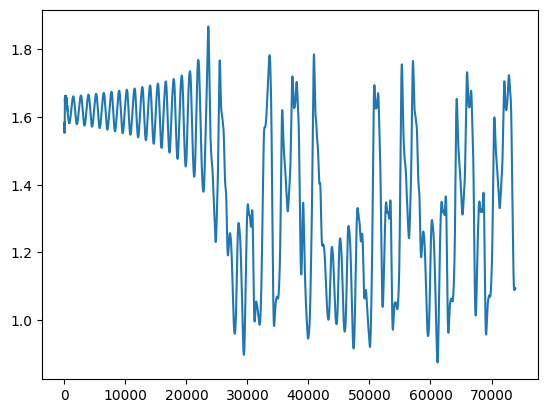

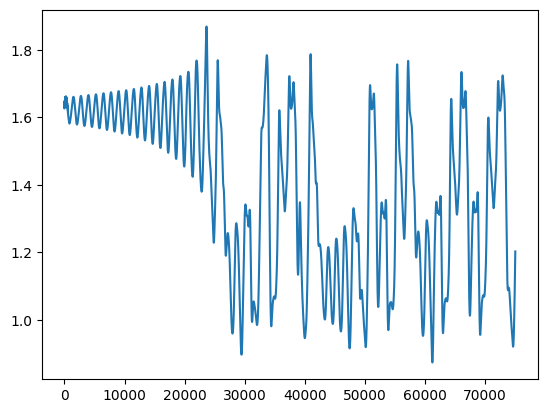

In [52]:
data = np.load("output_MZI.npz")
look_at_value = 23
xpos = data["output_pos_save_real"] + 1j*data["output_pos_save_imag"]
xneg = data["output_neg_save_real"] + 1j*data["output_neg_save_imag"]
xpos_weighted = xpos_old[:,look_at_value]*weights_pos[look_at_value]
plt.plot((np.abs(xpos[look_at_value,100:])*15)**2)
plt.show()
plt.plot(np.abs(xpos_weighted)**2)
plt.show()


In [59]:
pos_sum = np.sum(xpos,axis = 0)
neg_sum = np.sum(xneg,axis = 0)
Y = (np.abs(pos_sum)**2 - np.abs(neg_sum)**2)*225 + bias
print(Y)

[-0.5240516  -0.5240516  -0.5240516  ... -0.588591   -0.5889125
 -0.58922833]


In [54]:
sigma, rho, beta = 10.0, 28.0, 8/3

def lorenz(t, xyz):
    x, y, z = xyz
    return [
        sigma*(y - x),
        x*(rho - z) - y,
        x*y - beta*z,
    ]

dtt        = 0.05
n_train   = 400
n_test    = 700
n_warmup  = 100
total     = n_warmup + n_train + n_test   # 1101
t_eval    = np.linspace(0, dtt*total, total)

# solve
sol = solve_ivp(lorenz, (0, t_eval[-1]), (0.,1.,1.05),
                t_eval=t_eval, method="RK45")
xyz = sol.y.T
x, y_, z_ = xyz.T

# normalize to [−1,1]
def minmax(u):
    return 2*(u - u.min())/(u.max() - u.min()) - 1

# coarse → fine upsampling
N_coarse = 1000
t_coarse = np.arange(N_coarse)*dtt
upsample = 100
dt_fine  = dtt/upsample
t_fine   = np.linspace(0, t_coarse[-1], N_coarse*upsample)

cs = CubicSpline(t_coarse, x[:N_coarse])
x_f = cs(t_fine)
cs = CubicSpline(t_coarse, y_[:N_coarse])
y_f = cs(t_fine)
cs = CubicSpline(t_coarse, z_[:N_coarse])
z_f = cs(t_fine)

# base signals
x_norm  = minmax(x_f)
y_norm = minmax(y_f)
z_norm       = minmax(z_f)

In [55]:
data = np.load("X_mmi_binary_10.npz")
X_re    = data["X_re"]
X_im    = data["X_im"]
y = data["labels"]

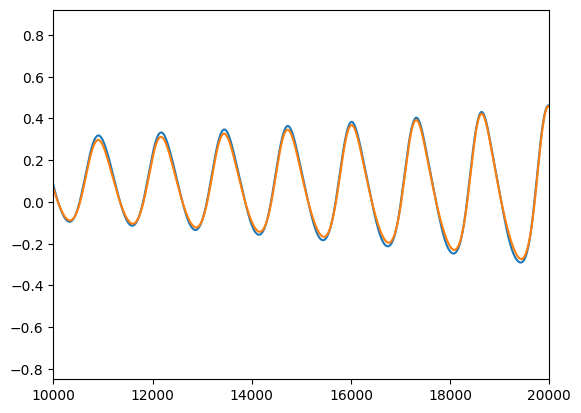

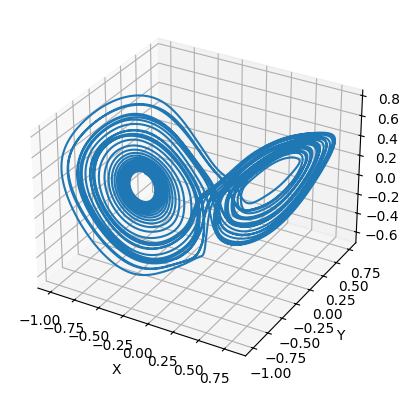

In [88]:
plt.plot(Y[60:])
plt.plot(y[:len(Y)])
plt.xlim(10000,20000)
plt.show()
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot(x_norm[6000:78940],y_norm[6000:78940], Y[1060:])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()
